# Лабораторная работа №1. Кластеризация
# Вариант 14 
# ПМИ3-1 Лязер Г.В.

## Задание:
> 1. Скачать набор данных согласно своему варианту. Привести описание исследуемых показателей.
> 2. Для 2 базовых показателей построить диаграмму рассеивания. Предположить, чему будет равно оптимальное число кластеров (К1).
> 3. Провести расчеты с помощью метода «локтя», построить график. Предположить, чему здесь будет равно оптимальное число кластеров (К2). *Примечание: крайне желательно, чтобы К1 и К2 были разные.*
> 4. Провести кластеризацию методом К-средних для обоих случаев (К1 и К2), рассчитать средние силуэтные коэффициенты, обосновать выбор лучшего разбиения.
> 5. Построить диаграмму рассеивания, на которой наблюдения из разных кластеров будут выделены соответствующими цветами, и нанесены центроиды.
> 6. Добавить к выборке дополнительный показатель. Разделить выборку на обучающую и прогнозную в соотношении 80%-20%.
> 7. С помощью метода «локтя» обосновать лучшее разбиение с учетом третьего фактора. Как изменилось это значение?
> 8. Провести кластеризацию на обучающей выборке. Визуально проанализировать статистическое распределение в кластерах.
> 9. Построить прогноз для прогнозной выборки.

***Дополнительное задание:***
Провести оценку точности кластеризации с помощью Acc, сравнив оценки с фактическим разбиением на группы.

## Данные по варианту:
|№|Набор данных (функция для получения)|Базовые признаки X|Дополнительные признаки X|
|:-:|:--:|:-:|:-:|
|14|<a src=https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris>load_iris</a>|sepal width in cm <br> petal width in cm|sepal length in cm|

In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import seaborn
from sklearn.metrics import silhouette_samples
import random
seaborn.set_theme()

### Импортир данных

In [16]:
from sklearn.datasets import load_iris
Df = load_iris(return_X_y=True, as_frame=True)
X = Df[0][['sepal width (cm)', 'petal width (cm)']]
y = Df[1]

In [17]:
X

,sepal width (cm),petal width (cm)
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2
3,3.1,0.2
4,3.6,0.2
...,...,...
145,3.0,2.3
146,2.5,1.9
147,3.0,2.0
148,3.4,2.3


### Диаграммма рассеивания по `sepal width in cm` и `petal width in cm`

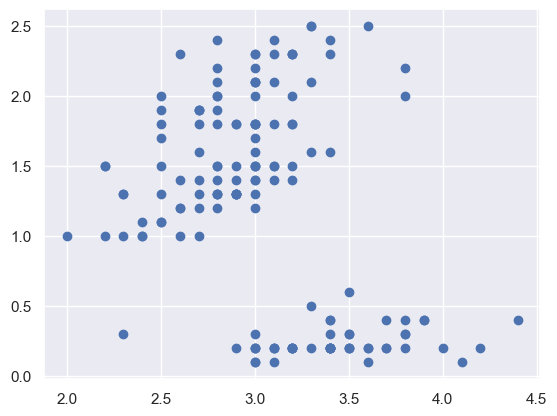

In [28]:
plt.scatter(X['sepal width (cm)'], X['petal width (cm)'])

Судя по полученному графику разброса, можем предположить наличие ***двух*** кластеров (K1 = 2).

In [19]:
K1 = 2

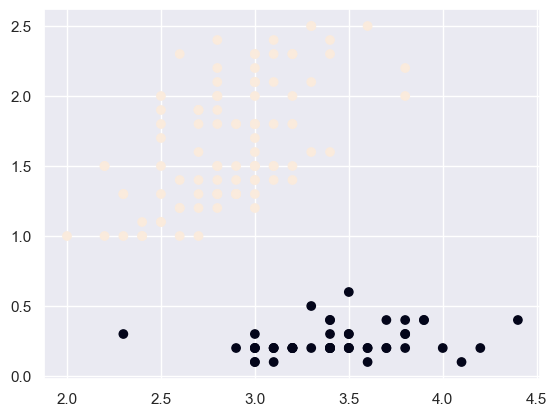

In [29]:
kmeans = KMeans(n_clusters=K1,random_state=0).fit(X.values)
plt.scatter(X['sepal width (cm)'], X['petal width (cm)'], c=kmeans.labels_)

---

### Определим число кластеров методом "локтя"

Text(0, 0.5, 'Искажение ')

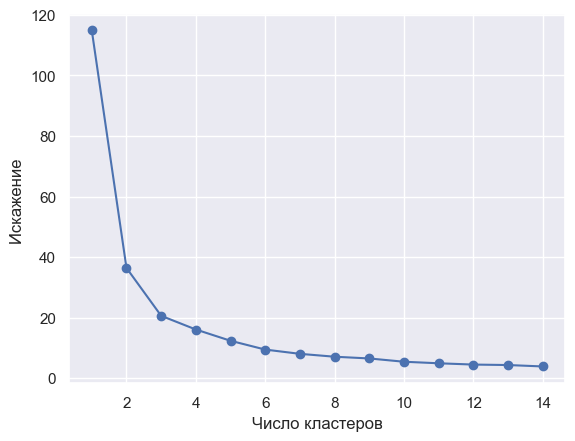

In [21]:
distortions = [] 
for i in range (1, 15): 
    km = KMeans(n_clusters=i, 
                init='random', 
                n_init=10 , 
                max_iter=300, 
                random_state=0) 
    km.fit(X)
    distortions.append(km.inertia_) 
plt.plot(range(1, 15) , distortions , marker='o') 
plt.xlabel('Чиcлo кластеров') 
plt.ylabel ('Искажение ' ) 

Судя по полученному графику, предположим оптимальное колличество кластеров равное 3 (K2 = 3)

In [22]:
K2 = 3

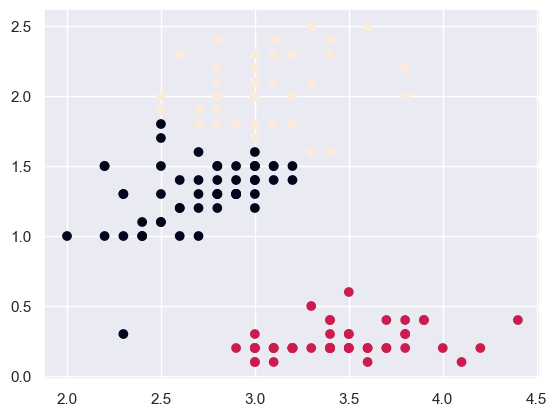

In [23]:
kmeans = KMeans(n_clusters=K2,random_state=0).fit(X.values)
plt.scatter(X['sepal width (cm)'], X['petal width (cm)'], c=kmeans.labels_)

---

### Кластеризация k-means

In [24]:
k1means = KMeans(n_clusters=K1, random_state=0).fit(X.values)
k2means = KMeans(n_clusters=K2, random_state=0).fit(X.values)

y_k1m = k1means.fit_predict(X)
y_k2m = k2means.fit_predict(X)

silhouette_vals1 = silhouette_samples(X, y_k1m, metric='euclidean')
silhouette_avg1 = np.mean(silhouette_vals1)
silhouette_vals2 = silhouette_samples(X, y_k2m, metric='euclidean')
silhouette_avg2 = np.mean(silhouette_vals2) 

print ("Средний коэффициент силуэта k1 -- ", silhouette_avg1)
print ("Средний коэффициент силуэта k2 -- ", silhouette_avg2)

Средний коэффициент силуэта k1 --  0.6273425371868404
Средний коэффициент силуэта k2 --  0.5286391856727592


Так как коэффициент силлуэта при k1 ближе к 1 (0.63 > 0.53 (при k2)), можем сделать вывод, что разбиение на 2 кластера является более точным и следут выбрать его.

---

In [32]:
my_seed = 14

X1 = Df[0].drop('petal length (cm)', axis = 1)
X_train = X1.sample(frac=.8, random_state=my_seed)
X_test = X1.drop(X_train.index)

Text(0, 0.5, 'Искажение ')

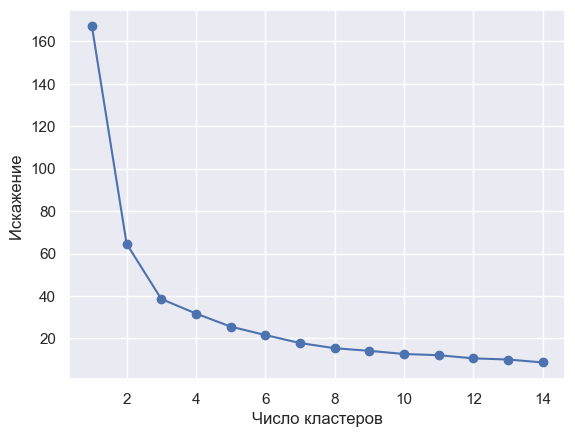

In [33]:
distortions = [] 
for i in range (1, 15): 
    km = KMeans(n_clusters=i, 
                init='random', 
                n_init=10 , 
                max_iter=300, 
                random_state=0) 
    km.fit(X_train)
    distortions.append(km.inertia_) 
plt.plot(range(1, 15) , distortions , marker='o') 
plt.xlabel('Чиcлo кластеров') 
plt.ylabel ('Искажение ' ) 

С учетом третьего фактора картина координально не меняется. По методу "локтя" предположим оптимальным разбиение на 3 кластера.

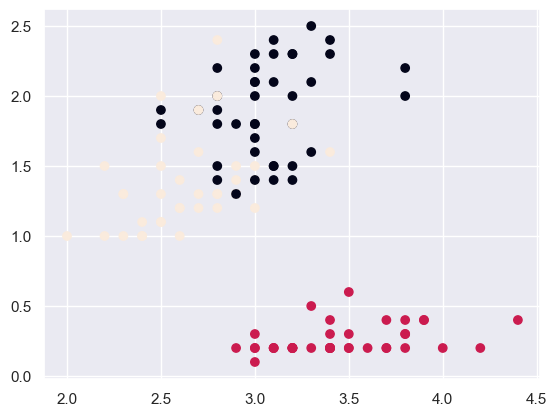

In [34]:
kmeans_train = KMeans(n_clusters=3, random_state=0).fit(X_train.values)
plt.scatter(X_train['sepal width (cm)'], X_train['petal width (cm)'], c=kmeans_train.labels_)

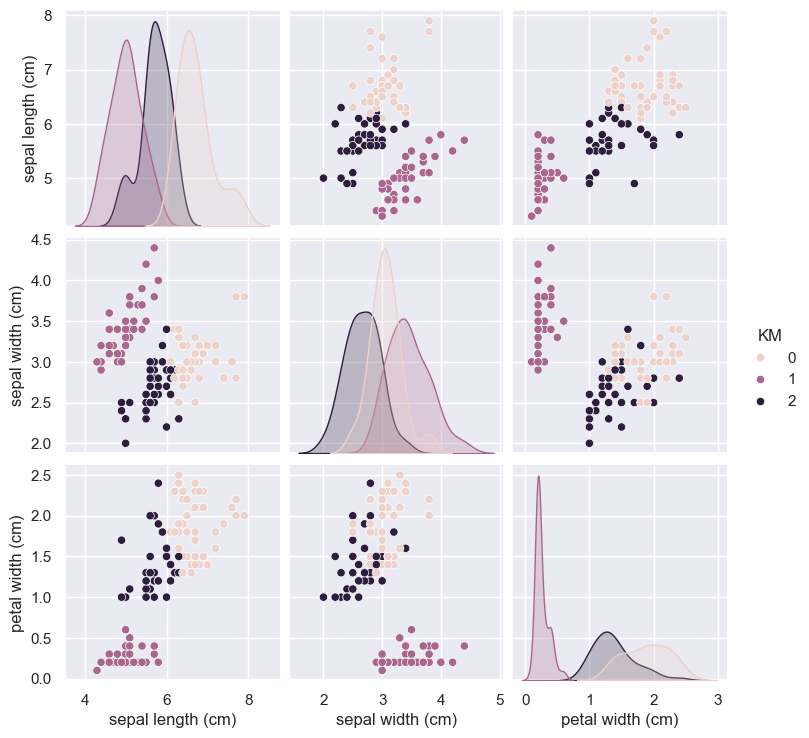

In [35]:
X_train['KM'] = kmeans_train.fit_predict(X_train)
seaborn.pairplot(X_train, hue='KM')
plt.show()

In [36]:
X_test['KM'] = kmeans_train.fit_predict(X_test)

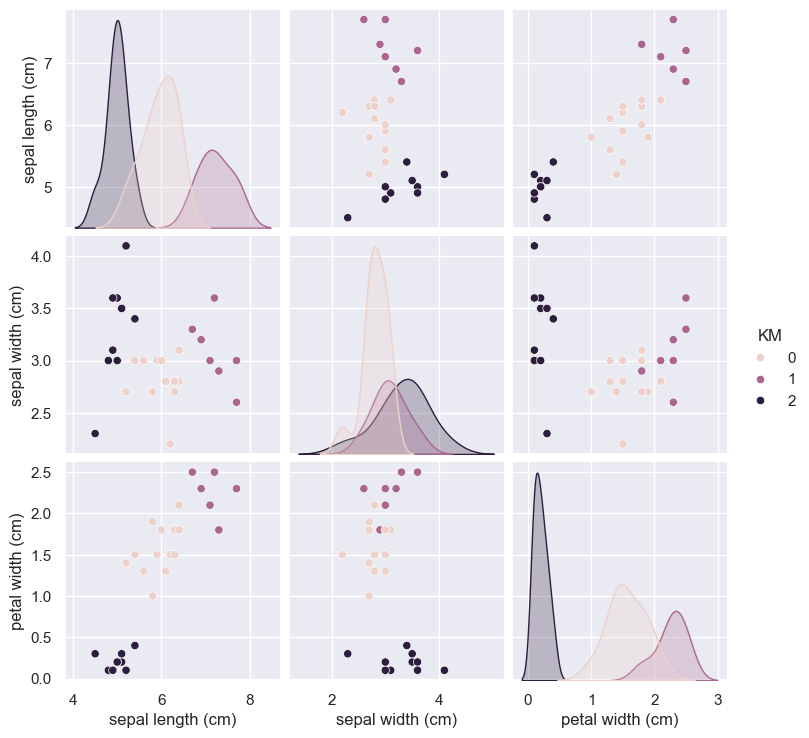

In [38]:
seaborn.pairplot(X_test, hue='KM')
plt.show()